# https://www.kaggle.com/datasets/shree1992/housedata

In [ ]:
#!/bin/bash
!kaggle datasets download shree1992/housedata

Dataset URL: https://www.kaggle.com/datasets/shree1992/housedata
License(s): unknown
  0% 0.00/432k [00:00<?, ?B/s]
100% 432k/432k [00:00<00:00, 47.6MB/s]


In [ ]:
!unzip housedata.zip

Archive:  housedata.zip
  inflating: data.csv                
  inflating: data.dat                
  inflating: output.csv              


In [ ]:
import pandas as pd

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


## Czyszczenie danych

In [ ]:
df = df[(df['price'] < 1e7) & (df['price'] > 1)]  # usuwam najdroższe nieruchomości oraz najtańsze nieruchomości

In [ ]:
y = df['price']
X = df['sqft_living']

In [ ]:
X = X * 0.0929 # jak zamienić X na m2

69700802084.91727


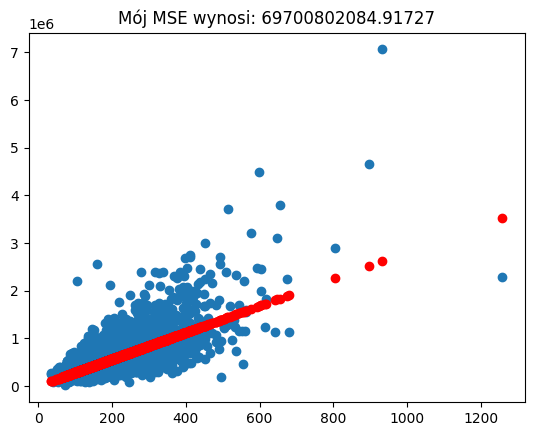

In [ ]:
y_pred = X * 2800 + 0 # regresja liniowa ogranicza mnie to takiej zależności, model
err = y - y_pred  # to są moję błędy
mse = (err**2).mean()  #  mean square error (sse), błędy mają być jak najmniejsze
print(mse)
plt.scatter(X, y)
plt.title(f"Mój MSE wynosi: {mse}")
plt.scatter(X, y_pred, color='red')
plt.show()

In [ ]:
mse

103023295261.44653

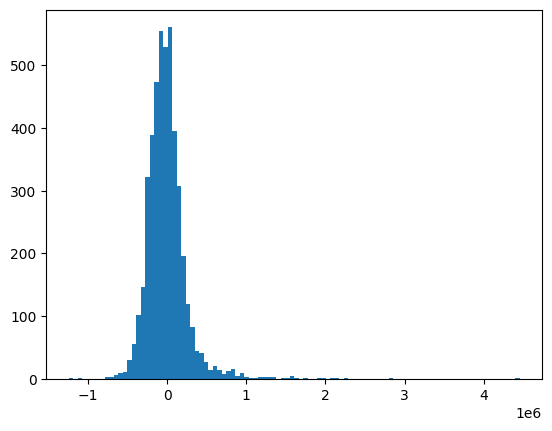

In [ ]:
plt.hist(err, bins=100)  # to ma być rozkład normalny
plt.show()

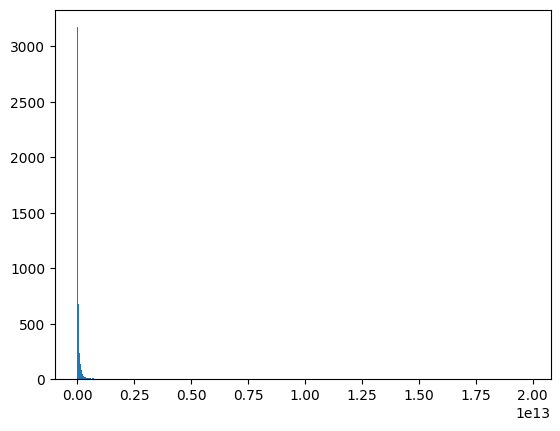

In [ ]:
plt.hist(err**2, bins=500)  # to ma być rozkład chi kwadrat
plt.show()

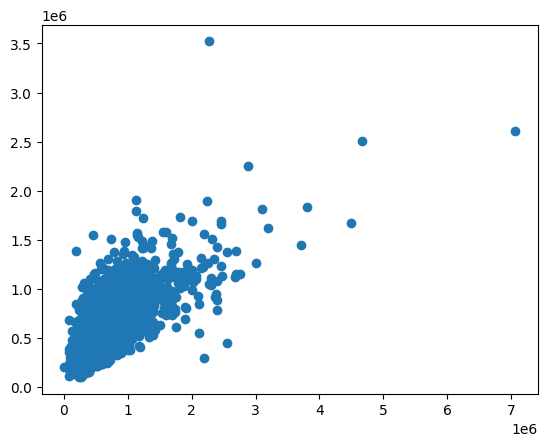

In [ ]:
plt.scatter(y, y_pred)
plt.show()

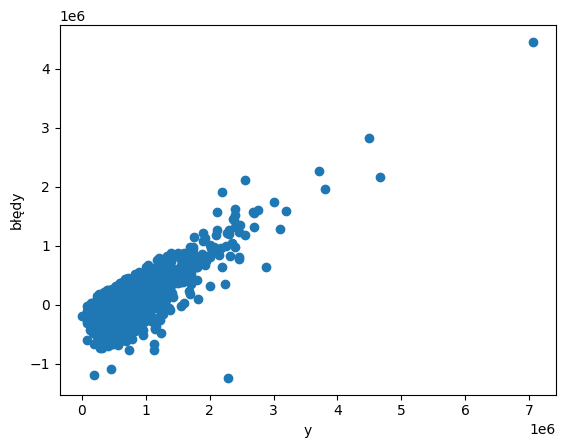

In [ ]:
plt.scatter(y, err)  # err i y powinny być od siebie niezależne, korelacja powinna być bliska 0
plt.xlabel('y')
plt.ylabel('błędy')
plt.show()

# Regresja liniowa teoria: https://en.wikipedia.org/wiki/Linear_regression

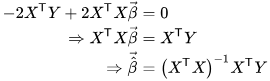

Zadanie domowe

X = [1], metry kwadratowe, inne zmienne  
y = ceny mieszkań

XT - transpozycja
X-1 - macierz odwrotna do macierzy X
X.T@y

# Scikitlearn - uczenie maszynowe (bez sztucznych sieci neuronowych)
https://scikit-learn.org/stable/

In [ ]:
from sklearn import linear_model

In [ ]:
reg = linear_model.LinearRegression()

In [ ]:
y = df[['price']]
X = df[['sqft_living']] * 0.0929

In [ ]:
type(y)

pandas.core.frame.DataFrame

In [ ]:
reg.fit(X, y)

LinearRegression()

In [ ]:
reg.intercept_, reg.coef_

(array([-23457.01044746]), array([[2891.88350936]]))

In [ ]:
reg.coef_
reg.intercept_

array([-23457.01044746])

In [ ]:
y_pred = (X * reg.coef_ + reg.intercept_)['sqft_living']  # obliczanie predykcji

In [ ]:
mse = ((y_pred - y['price'])**2).mean()  # metoda ręczna: 69700802084.91727

## Obliczenia predykcji

In [ ]:
y_pred = reg.predict(X)

# Obliczenie współczynnika determinacji R kwadrat

In [ ]:
reg.score(X, y)  # w jaki stopniu model jest w stanie wyjaśnić zmienność wyników z naszej zmiennej zależnej

0.48654056725077155

In [ ]:
y_pred.var()/y['price'].var()

0.48643361175126654

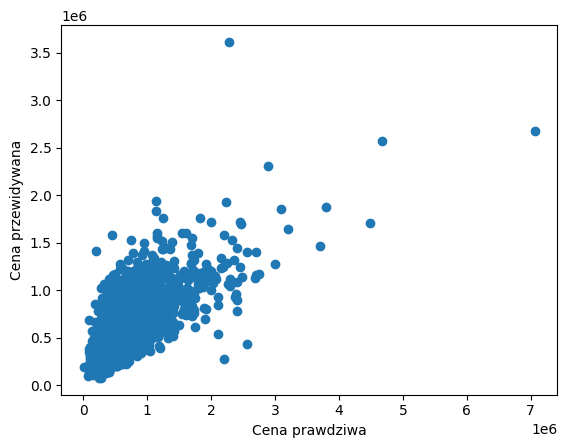

In [ ]:
plt.scatter(y, y_pred)
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")
plt.show()

Model regresji, ale z wieloma zmiennymi niezależnymi

In [ ]:
reg = linear_model.LinearRegression()

In [ ]:
X, y = df.drop('price', axis=1).select_dtypes(include='number') , df['price']

In [ ]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

In [ ]:
reg.fit(X, y)

LinearRegression()

In [ ]:
reg.coef_

array([-5.57052616e+04,  5.32108209e+04,  1.74646979e+02, -7.32728823e-01,
        5.62718669e+04,  4.74282251e+05,  5.24244329e+04,  2.93880779e+04,
        1.03028184e+02,  7.16187958e+01, -2.66459013e+03,  7.09586076e+00])

In [ ]:
reg.score(X, y)

0.5797203136128826

In [ ]:
reg.predict(X)

array([ 352586.69037454, 1299166.82470922,  497778.33827052, ...,
        740193.88930595,  407654.6473427 ,  397345.72321026])

In [ ]:
y_pred = reg.predict(X)

Text(0, 0.5, 'Cena przewidywana')

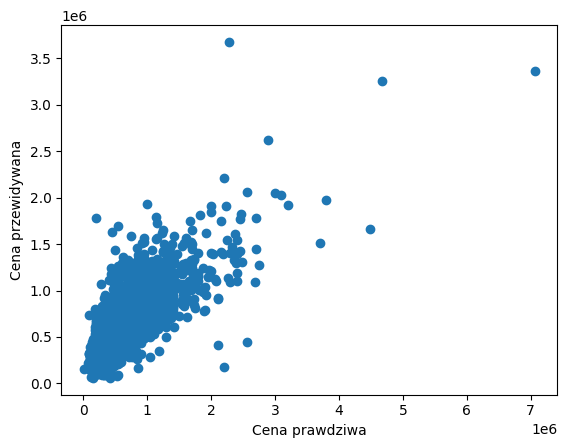

In [ ]:
plt.scatter(y, y_pred)
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")

## Analiza korelacji pomiedzy zmiennych

In [ ]:
import seaborn as sns

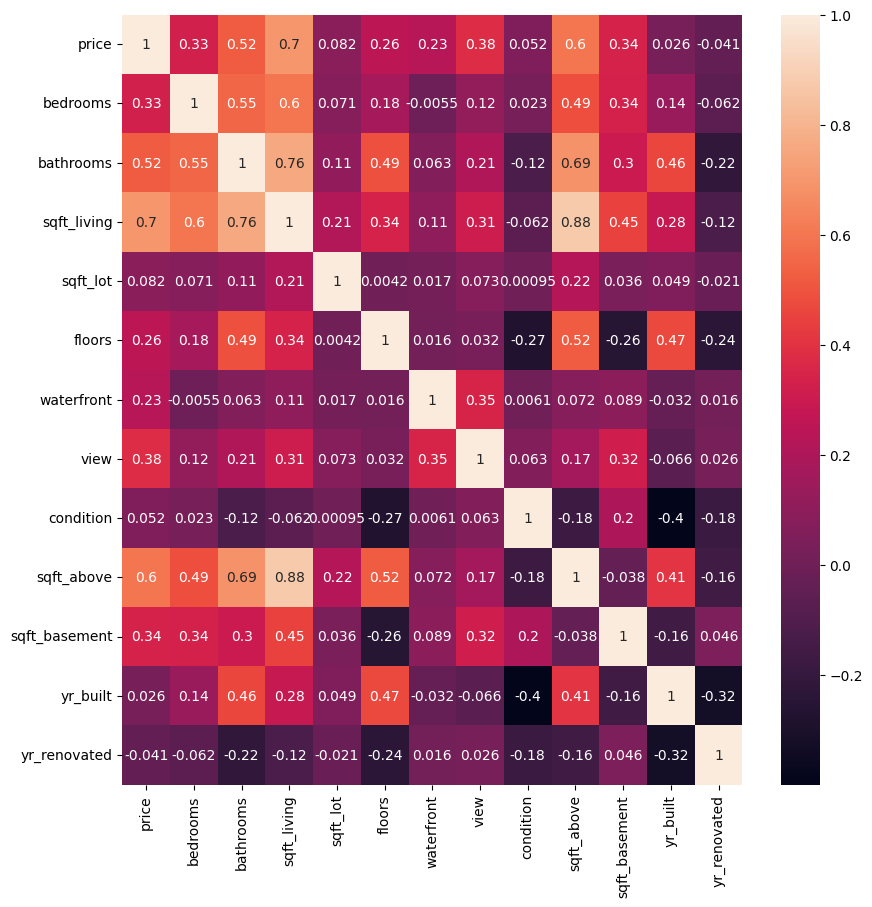

In [ ]:
df_corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 10))
sns.heatmap(df_corr, annot=True)
plt.show()

In [ ]:
sel_var = list(df_corr.loc['price'][df_corr.loc['price'] > 0.3].index)  # wybieram kolumny, których korelacja z zmienną cena jest powyżej 0.3

In [ ]:
sel_var

['price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'view',
 'sqft_above',
 'sqft_basement']

In [ ]:
# policzyć korelacje
df[sel_var].corr()

,price,bedrooms,bathrooms,sqft_living,view,sqft_above,sqft_basement
price,1.000000,0.332038,0.522377,0.697525,0.378629,0.597172,0.338806
bedrooms,0.332038,1.000000,0.547672,0.596054,0.115029,0.485625,0.335156
bathrooms,0.522377,0.547672,1.000000,0.757266,0.205562,0.687274,0.295772
sqft_living,0.697525,0.596054,0.757266,1.000000,0.309320,0.875656,0.449611
view,0.378629,0.115029,0.205562,0.309320,1.000000,0.174573,0.317160
sqft_above,0.597172,0.485625,0.687274,0.875656,0.174573,1.000000,-0.037664
sqft_basement,0.338806,0.335156,0.295772,0.449611,0.317160,-0.037664,1.000000


# Model dla wybranych zmiennych

In [ ]:
df['yr_renovated'].value_counts()

,count
yr_renovated,
0,2705
2000,169
2003,150
2009,107
2001,105
2005,94
2004,77
2014,72
2006,66


In [ ]:
X, y = df[sel_var].drop('price', axis=1), df['price']

In [ ]:
reg.fit(X, y)

LinearRegression()

In [ ]:
reg.score(X, y)

0.5240590764424499

## Feature engineering

In [ ]:
df['room_bath'] = df['bedrooms']/(df['bathrooms'] + 0.01)
df['old_not_renovated'] = (df['yr_built'] < 1951) & (df['yr_renovated'] == 0)
df['pct_above'] = (df['sqft_above'])/(df['sqft_above'] + df['sqft_basement']) * 100

In [ ]:
#  df.drop(columns = ['above_below'], inplace=True, errors='ignore')

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4549.0,549470.377440,368230.654130,7800.000000,326100.000000,465000.000000,657500.000000,7.062500e+06
bedrooms,4549.0,3.394812,0.904756,0.000000,3.000000,3.000000,4.000000,9.000000e+00
bathrooms,4549.0,2.154979,0.776502,0.000000,1.750000,2.250000,2.500000,8.000000e+00
sqft_living,4549.0,2132.568916,956.055181,370.000000,1460.000000,1970.000000,2610.000000,1.354000e+04
sqft_lot,4549.0,14837.585184,35971.796788,638.000000,5000.000000,7680.000000,10970.000000,1.074218e+06
floors,4549.0,1.512420,0.538543,1.000000,1.000000,1.500000,2.000000,3.500000e+00
waterfront,4549.0,0.006595,0.080949,0.000000,0.000000,0.000000,0.000000,1.000000e+00
view,4549.0,0.234777,0.765525,0.000000,0.000000,0.000000,0.000000,4.000000e+00
condition,4549.0,3.449330,0.675226,1.000000,3.000000,3.000000,4.000000,5.000000e+00
sqft_above,4549.0,1822.422730,854.578127,370.000000,1190.000000,1590.000000,2300.000000,9.410000e+03


In [ ]:
df['old_not_renovated'] = df['old_not_renovated'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4549 entries, 0 to 4599
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               4549 non-null   object 
 1   price              4549 non-null   float64
 2   bedrooms           4549 non-null   float64
 3   bathrooms          4549 non-null   float64
 4   sqft_living        4549 non-null   int64  
 5   sqft_lot           4549 non-null   int64  
 6   floors             4549 non-null   float64
 7   waterfront         4549 non-null   int64  
 8   view               4549 non-null   int64  
 9   condition          4549 non-null   int64  
 10  sqft_above         4549 non-null   int64  
 11  sqft_basement      4549 non-null   int64  
 12  yr_built           4549 non-null   int64  
 13  yr_renovated       4549 non-null   int64  
 14  street             4549 non-null   object 
 15  city               4549 non-null   object 
 16  statezip           4549 non-n

In [ ]:
df.select_dtypes(include='number').columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'old_not_renovated', 'room_bath',
       'pct_above'],
      dtype='object')

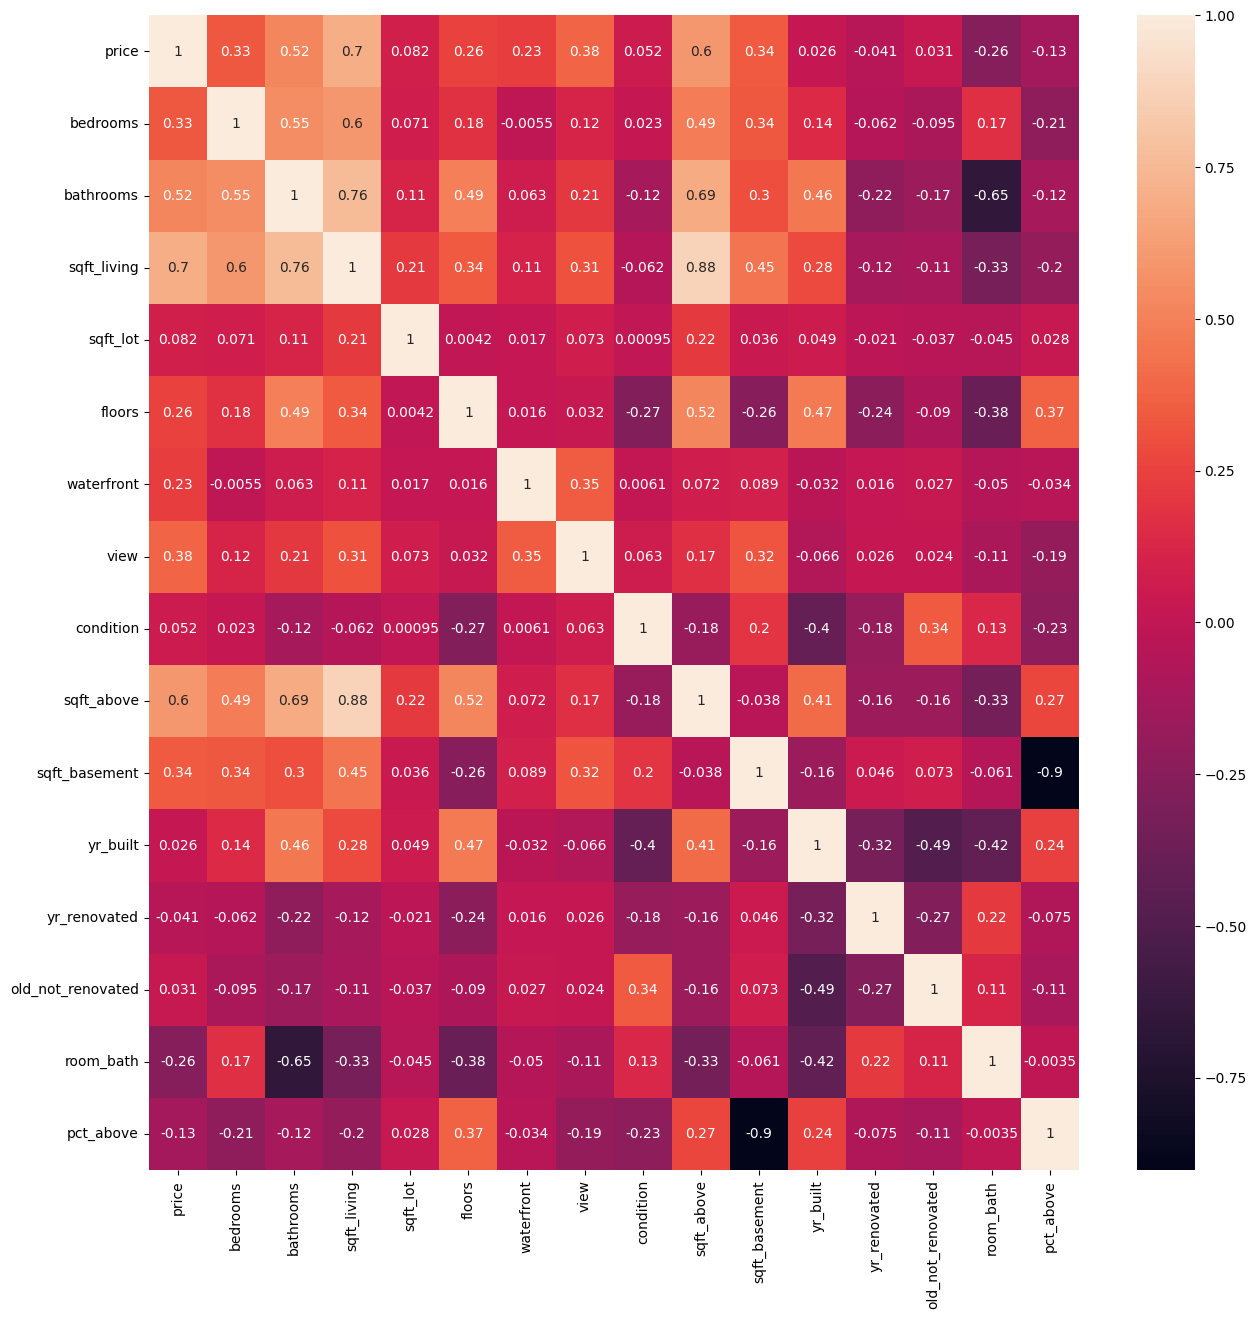

In [ ]:
df_corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(15, 15))
sns.heatmap(df_corr, annot=True)
plt.show()

In [ ]:
df.isna().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
X, y = df.drop('price', axis=1).select_dtypes(include='number'), df['price']
reg.fit(X, y)
reg.score(X, y)

In [ ]:
reg.fit(X, y)
reg.score(X, y)

0.5830730813146582

# Dodanie informacji o lokalizacji

In [ ]:
df['city'].value_counts() #  street	city	statezip	country

,count
city,
Seattle,1560
Renton,291
Bellevue,281
Redmond,235
Kirkland,187
Issaquah,186
Kent,183
Auburn,175
Sammamish,171


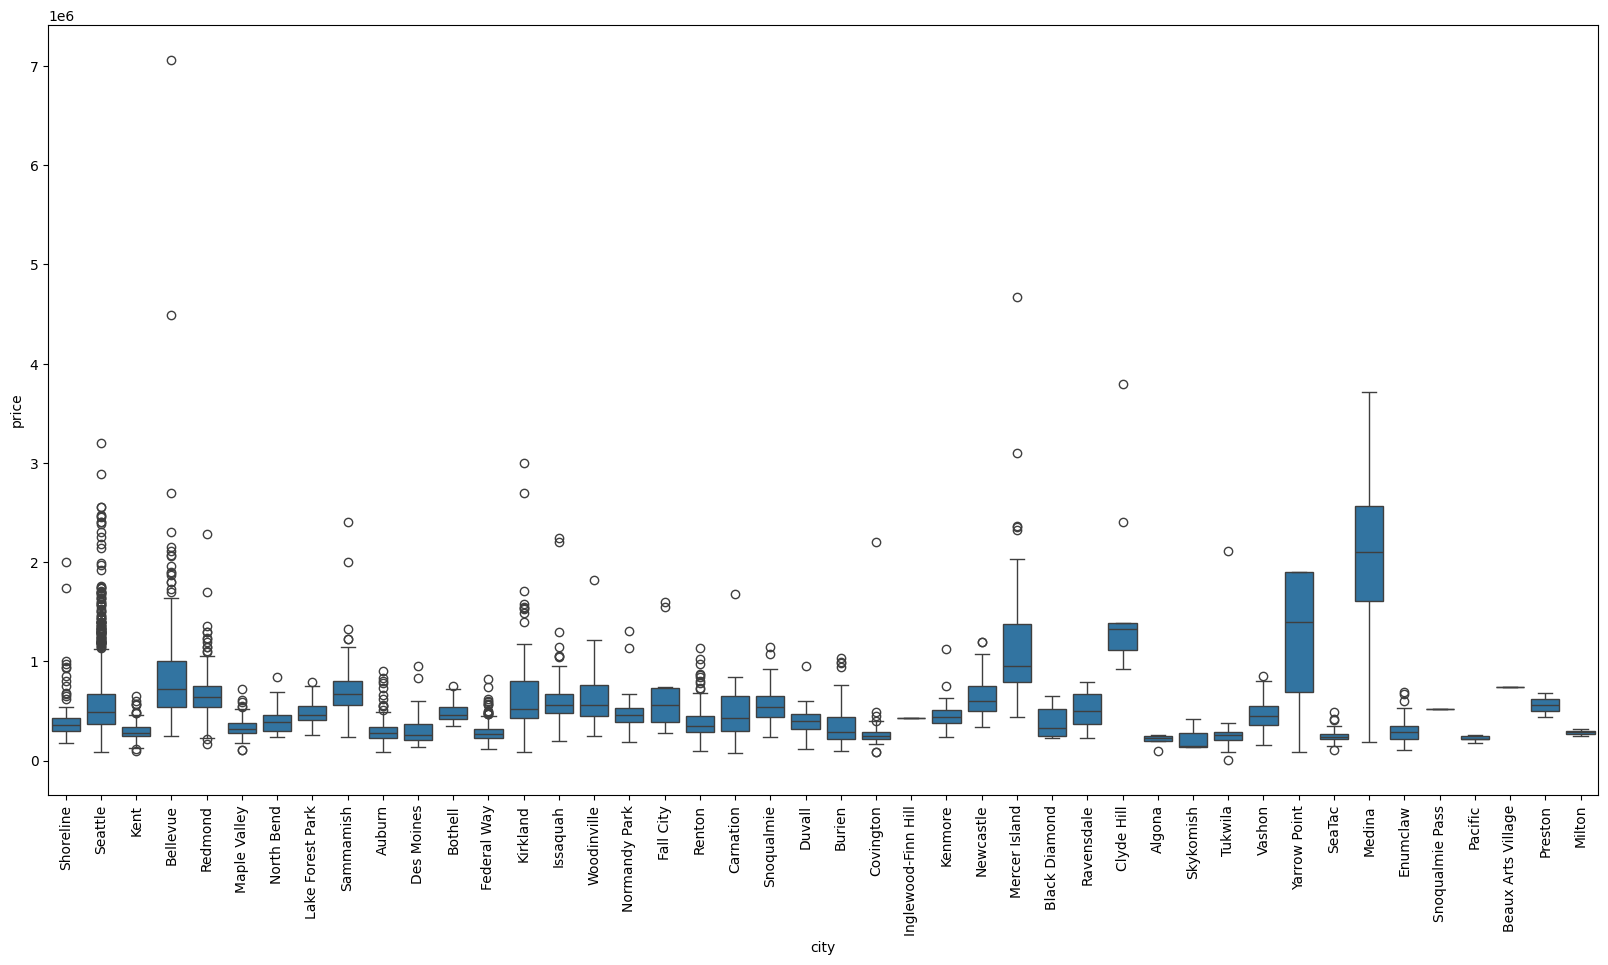

In [ ]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='city', y='price', data=df)
plt.xticks(rotation=90)
plt.show()

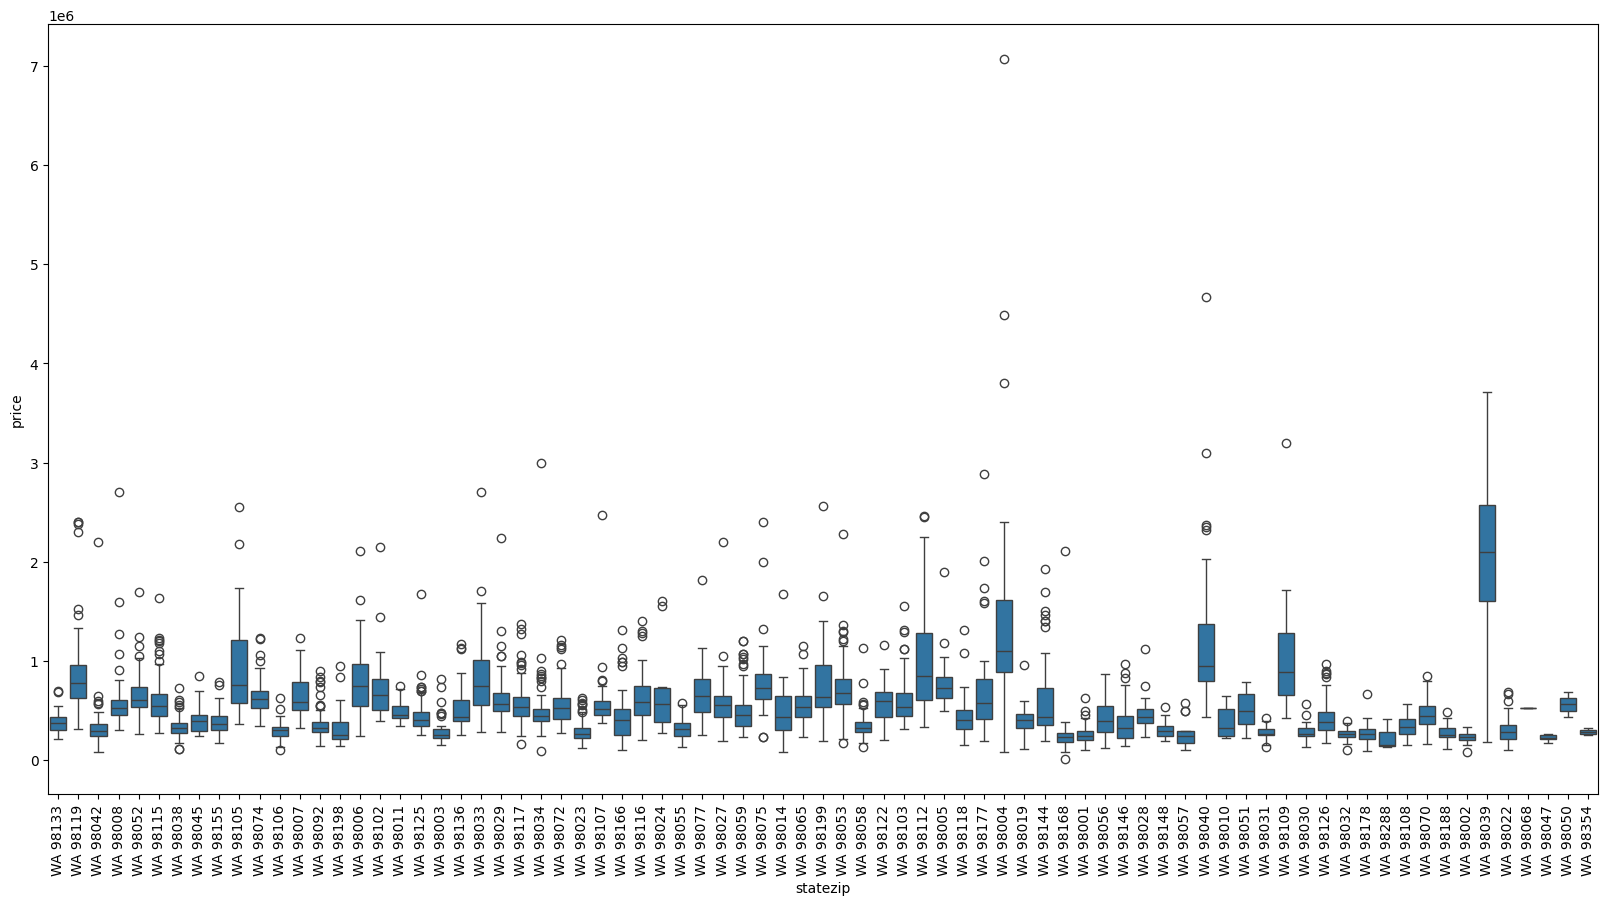

In [ ]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='statezip', y='price', data=df)
plt.xticks(rotation=90)
plt.show()

### Tworzenie zmiennych dummy, onehot dla miasta

In [ ]:
len(df['city'].unique())

44

In [ ]:
df_city = pd.get_dummies(df['city'])

In [ ]:
df = pd.concat((df, df_city), axis=1)

In [ ]:
X, y = df.drop('price', axis=1).select_dtypes(include=['number', 'bool']), df['price']
reg.fit(X, y)
reg.score(X, y)

In [ ]:
df = pd.get_dummies(df)

In [ ]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354,country_USA
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,True
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,True
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,True
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,True
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,...,False,False,False,False,False,False,False,False,False,True
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,...,False,False,False,False,False,False,False,False,False,True
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,...,False,False,False,False,False,False,False,False,False,True
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above',
       ...
       'statezip_WA 98166', 'statezip_WA 98168', 'statezip_WA 98177',
       'statezip_WA 98178', 'statezip_WA 98188', 'statezip_WA 98198',
       'statezip_WA 98199', 'statezip_WA 98288', 'statezip_WA 98354',
       'country_USA'],
      dtype='object', length=4726)

### To jest model przeuczony

In [ ]:
X, y = df.drop('price', axis=1).select_dtypes(include=['number', 'bool']), df['price']
reg.fit(X, y)
reg.score(X, y)

0.9997123785293792

In [ ]:
y_pred = reg.predict(X)

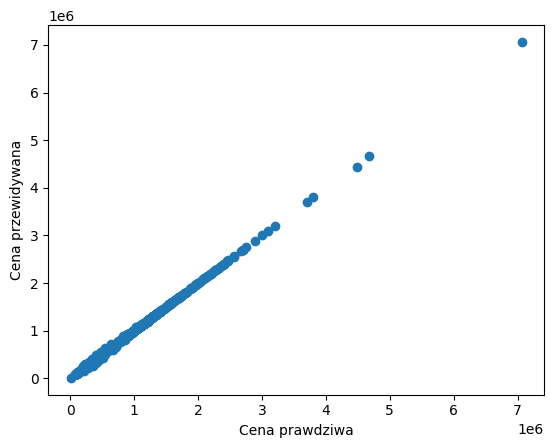

In [ ]:
plt.scatter(y, y_pred)
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")
plt.show()

# Walidacja modeli uczeania maszynowego (z nadzorowaniem)

*   train (zbiór uczący, treningowy, szkoleniowy)
*   test (zbiór testowy)

In [ ]:
from sklearn import model_selection

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.9, random_state=34521)  # ten kod ma pewna bąba bez parametru random_state

In [ ]:
X_train.shape, y_train.shape

((454, 4725), (454,))

In [ ]:
X_test.shape, y_test.shape

((4095, 4725), (4095,))

In [ ]:
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
reg.score(X_train, y_train), reg.score(X_test, y_test)

(1.0, 0.6381285216860713)

In [ ]:
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

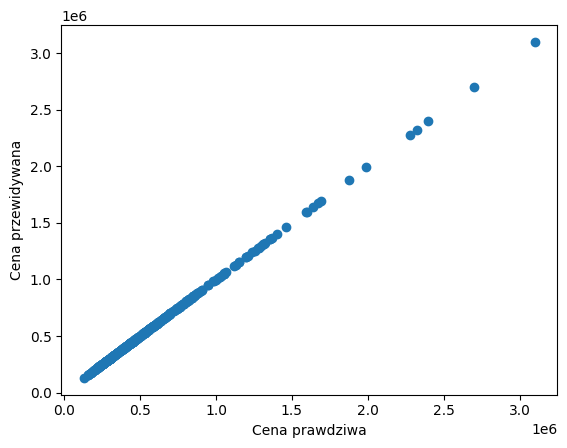

In [ ]:
plt.scatter(y_train, y_pred_train)
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")
plt.show()

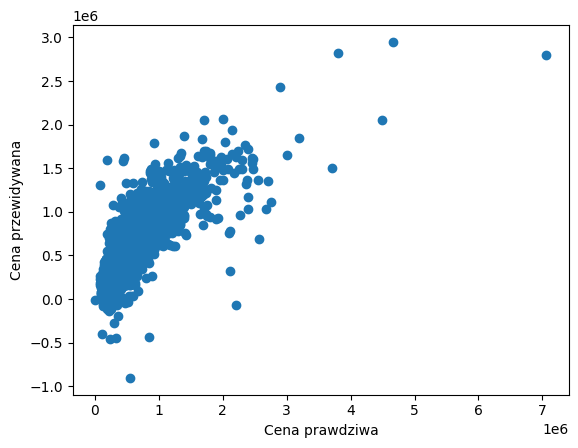

In [ ]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")
plt.show()

## Model jedynie z city i zmiennymi liczbowymi

In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
df = df[(df['price'] < 1e7) & (df['price'] > 1)]  # usuwam najdroższe nieruchomości oraz najtańsze nieruchomości

In [ ]:
df['room_bath'] = df['bedrooms']/(df['bathrooms'] + 0.01)
df['old_not_renovated'] = (df['yr_built'] < 1951) & (df['yr_renovated'] == 0)
df['pct_above'] = (df['sqft_above'])/(df['sqft_above'] + df['sqft_basement']) * 100
df['old_not_renovated'] = df['old_not_renovated'].astype(float)

In [ ]:
df = pd.get_dummies(df, columns=['city'])

In [ ]:
X, y = df.drop('price', axis=1).select_dtypes(include=['number', 'bool']), df['price']

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=2)  # ten kod ma pewna bąba bez parametru random_state

In [ ]:
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
reg.score(X_train, y_train), reg.score(X_test, y_test)

(0.6994935154941273, 0.7164498906734985)

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=2)
reg.fit(X_train, y_train)
reg.score(X_train, y_train), reg.score(X_test, y_test)

(0.6994935154941273, 0.7164498906734985)

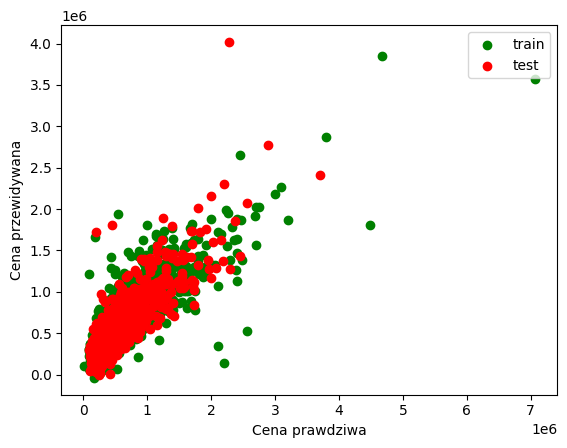

In [ ]:
plt.scatter(y_train, reg.predict(X_train), color='green')
plt.scatter(y_test, reg.predict(X_test), color='red')
plt.legend(['train', 'test'])
plt.xlabel("Cena prawdziwa")
plt.ylabel("Cena przewidywana")
plt.show()

In [ ]:
y_pred = reg.predict(X)

In [ ]:
df = pd.read_csv('data.csv')
df = df[(df['price'] < 1e7) & (df['price'] > 1)]  # usuwam najdroższe nieruchomości oraz najtańsze nieruchomości

In [ ]:
df['y_pred'] = y_pred

In [ ]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,y_pred
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,3.022267e+05
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,1.265691e+06
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,3.528328e+05
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,6.364245e+05
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,4.630004e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA,5.334365e+05
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA,5.883881e+05
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA,6.108305e+05
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA,4.688562e+05


In [ ]:
df_selected = df[['price', 'y_pred', 'city']]

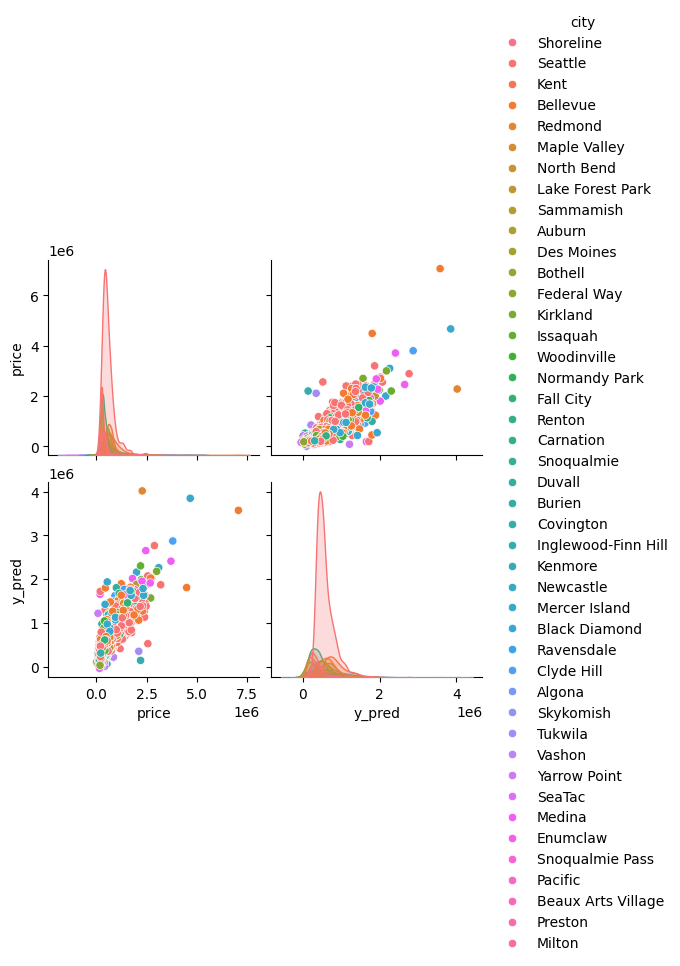

In [ ]:
sns.pairplot(df_selected, hue='city') # sns.pairplot(df, hue='city', vars=['price', 'y_pred'])
plt.show()

In [ ]:
df['pred_diff'] = df['price'] - df['y_pred']

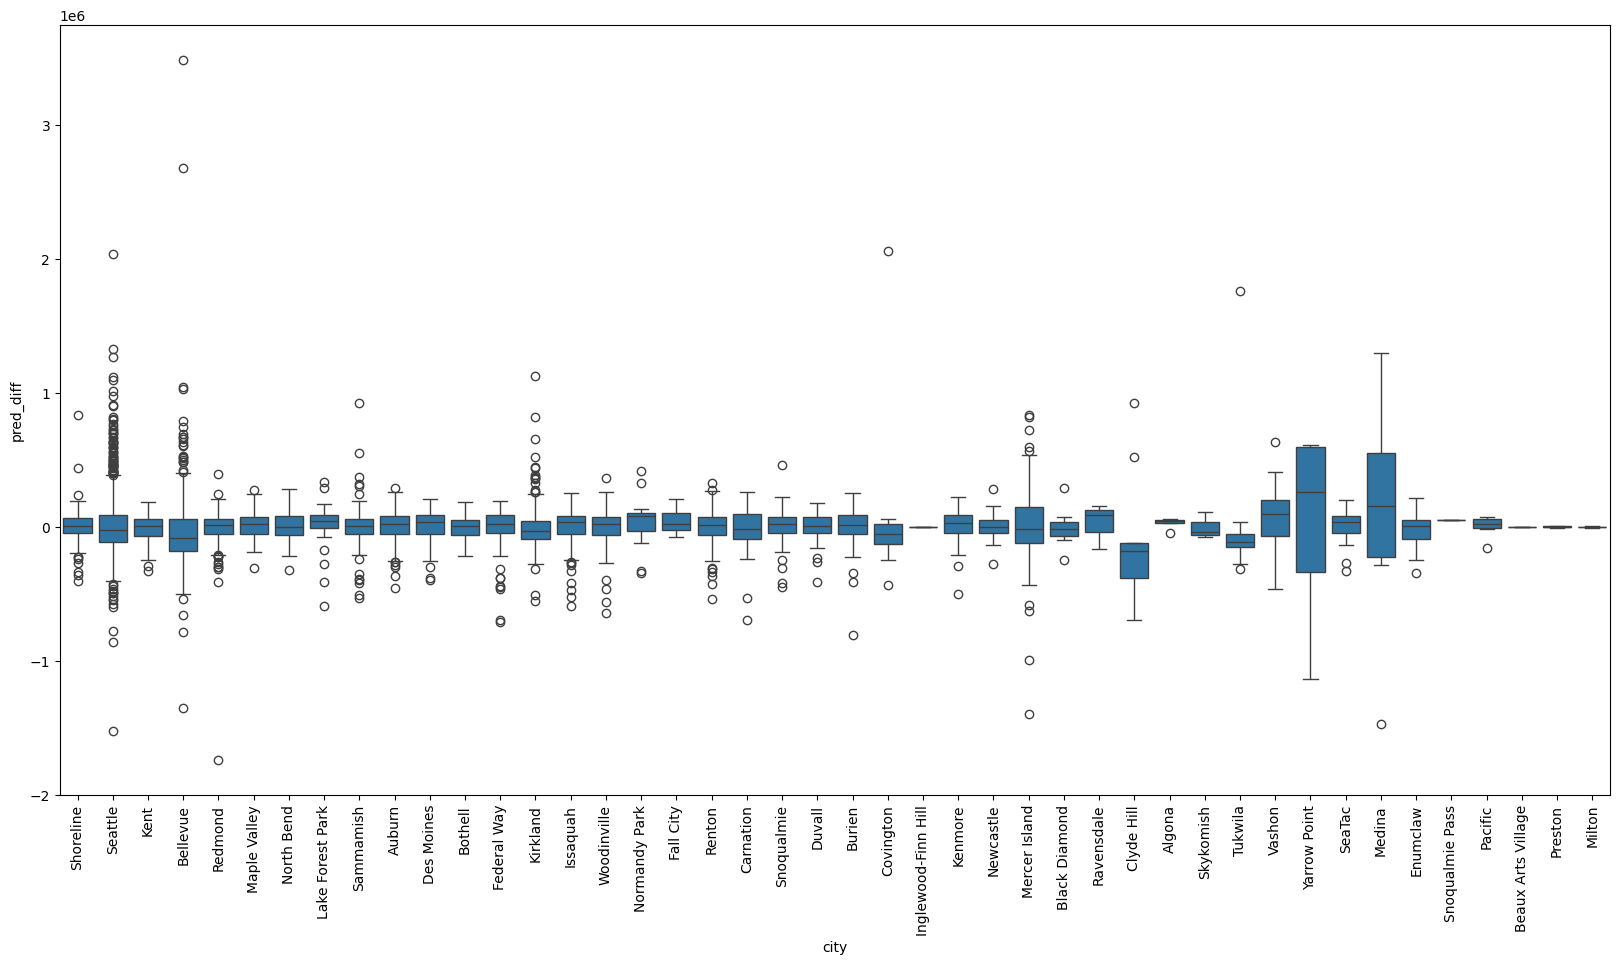

In [ ]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='city', y='pred_diff', data=df)

plt.xticks(rotation=90)
plt.show()